# Simulation of incompressible fluids with Optimal Transport

Now that we know how to solve an Optimal Transport problem, we are fully equiped to compute a fluid simulation based on our solver.

This tutorial starts with moving particles and then implement a discretization of Euler's equation thanks to the previously developed Optimal Transport solver.

## Prerequisites

Like previous tutorials, you need to install the dependencies with
```sh
pip install -r requirements.txt
```

as well as `geogram`'s python bindings with
```sh
pip install geogram
```

We can then import all required modules:

In [1]:
import geogram as geo
import numpy as np
from tqdm import trange, tqdm

import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.collections

import scipy
import geogram as geo

# Note that we freeze the seed to ensure everyone will have the same results.
np.random.seed(0)

## Warming up

We will start by a super-simple simulation with a couple of particles, then add complexity, one element at a time.

We start by creating a set of particles, let's call them *seeds*:

In [2]:
SEED_NB = 3000
SIZE = .02

INITIAL_SEEDS = np.random.rand(SEED_NB, 2)

We then need to plot these seeds. Since it's hard to deal with animations in Jupyter Notebooks, we prefer to plot mosaics of seeds positions.

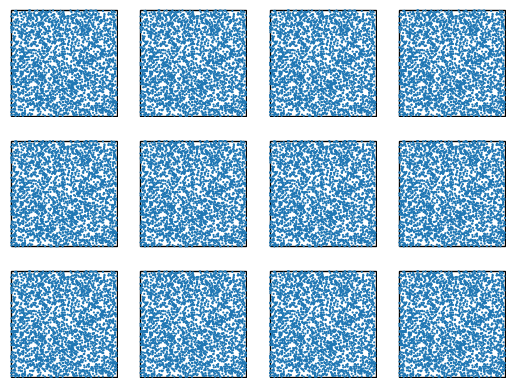

In [3]:
def plot_particles_sequence(seeds):
    if type(seeds) is list or type(seeds) is tuple:
        seeds = np.array(seeds)

    assert len(seeds.shape) == 3, 'seeds must be an ndarray with shape (seq, particle, dim)'

    img_nb    = len(seeds)
    fig, axes = plt.subplots( int( np.ceil(img_nb / 4) ), min( img_nb, 4 ) )
            
    for img in range(img_nb):
        current = seeds[img]
        n       = len(current)
        
        ax = axes if img_nb == 1 else (axes[img] if img_nb <= 4 else axes[img // 4, img % 4])

        # Faster than plotting 
        sizes = np.ones(n) * SIZE
        coll = matplotlib.collections.EllipseCollection(
            sizes, sizes, np.zeros_like(sizes), offsets=current, units='x', transOffset=ax.transData)

        ax.add_patch(
            matplotlib.patches.Rectangle((0, 0), 1, 1, color='black', fc = 'none',lw = 1))

        ax.add_collection(coll)
        ax.set_aspect('equal')
        ax.margins(0.01)
        ax.axis('off')


plot_particles_sequence([INITIAL_SEEDS] * 12)

### Step 1: a couple of particles

Then we initialize the points, at random positions and with random initial speeds as well as their masses.

In [4]:
points     = INITIAL_SEEDS
masses     = np.ones(SEED_NB)
velocities = np.random.rand(SEED_NB, 2) * 2. - 1.

#### First law of Newton

OK, so now let us move our points ! For now we have no force, so all the points will move along a straight line (first law of Newton). We create a new function to do one step of simulation:

In [5]:
def euler_step(seeds, velocities, tau=.005):
    tau = 0.005
    return seeds + tau*velocities

The function simply makes each point move along its speed vector. The parameter tau is the timestep, in seconds.

Now we can start our simulation and display its result:

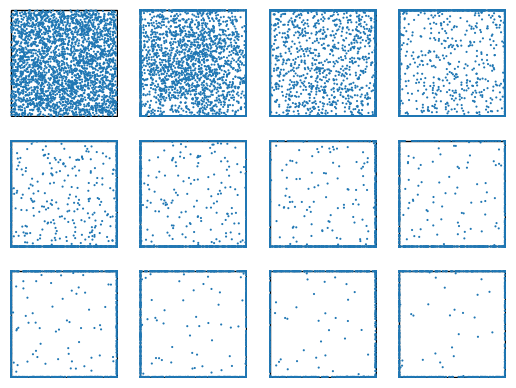

In [6]:
animation = [ points ]
for i in range(1000):
    animation    += [ euler_step(animation[-1], velocities) ]
    animation[-1] = np.clip(animation[-1], 0., 1.)

plot_particles_sequence(animation[::90])

each point moves along its speed vector, not super interesting for now. To make things more interesting, let us add gravity.

#### Second law of Newton

Newton's second law states that $F = ma$, where $F$ is the force applied to a particle, $m$ its mass and $a$ the acceleration. 

Put differently, it says that $a = \frac{1}{m} F$, which means that when we move from $t$ to $t + \tau$, the speed $V$ should be updated as $V^{t+1} = V^{t} + \tau a$, or $V^{t+1} = V^{t} + \frac{\tau}{m} F$.

Now which force do we have? For now we have gravity, oriented towards the negative Y axis, or $F = \left(0, -m G\right)$ where $G = 9.81$. 

Hence we update our euler_step() function as follows:

In [7]:
def euler_step(seeds, velocities, masses, tau=.005, g=9.81):
    f = -masses * g

    f = np.c_[np.zeros(len(masses)), -masses * g]
    v = velocities + tau*f / masses[:, np.newaxis]
    s = seeds + tau*v
    return s, v

Note here we used the simplest method (called "semi-explicit Euler") to approximate $F=ma$ with discrete timesteps (what is called "time integration"). More sophisticated methods exist (leapfrog, Verlet), with the advantage of better conserving quantities supposed to be conserved (energy, momentum).

OK so now when you compute the simulation, you see your points moving along nice parabolas, as expected, but soon the points move outside the domain.

100%|██████████| 100/100 [00:00<00:00, 19573.03it/s]


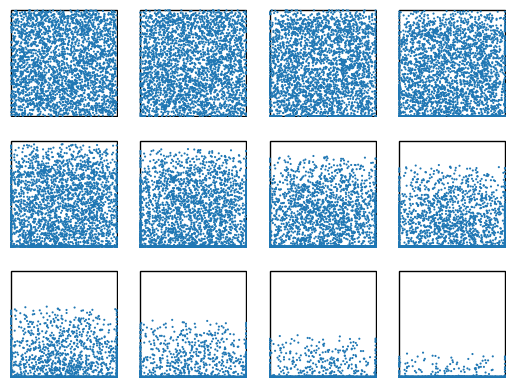

In [8]:
def euler_step(seeds, velocities, masses, tau=.005, g=9.81):
    f = -masses * g

    f = np.c_[np.zeros(len(masses)), -masses * g]
    v = velocities + tau*f / masses[:, np.newaxis]
    s = seeds + tau*v
    return s, v


masses     = np.ones(SEED_NB)
velocities = np.random.rand(SEED_NB, 2) * 2. - 1.

animation  = [ INITIAL_SEEDS ]
last_velocities = velocities
for i in trange(100):
    current_seeds, last_velocities = euler_step(animation[-1], last_velocities, masses)
    
    animation    += [ current_seeds ]
    animation[-1] = np.clip(animation[-1], 0., 1.)

plot_particles_sequence(animation[::9])

Could we make them bounce on the domain boundaries ? Yes, it is simple, if the x (resp. y) coordinate of the point is outside [0,1], change the sign of Vx (resp. Vy). In addition, whenever a collision with the domain boundary occurs, you can multiply the speed vector by a damping coefficient:

100%|██████████| 100/100 [00:00<00:00, 3423.36it/s]


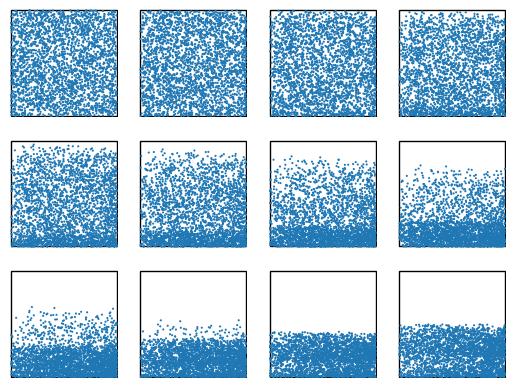

In [9]:
def bounce_on_border(seeds, velocities, damp=.9):
    if np.any(seeds[:, 0] >= 1.):
        velocities[seeds[:, 0] >= 1.] = velocities[seeds[:, 0] >= 1.] * (np.array([-1., 1.])[np.newaxis, :] * damp)
        seeds[seeds[:, 0] >= 1., 0] = 1.

    if np.any(seeds[:, 0] <= 0.):
        velocities[seeds[:, 0] <= 0.] = velocities[seeds[:, 0] <= 0.] * (np.array([-1., 1.])[np.newaxis, :] * damp)
        seeds[seeds[:, 0] <= 0., 0] = 1.

    if np.any(seeds[:, 1] >= 1.):
        velocities[seeds[:, 1] >= 1.] = velocities[seeds[:, 1] >= 1.] * (np.array([1., -1.])[np.newaxis, :] * damp)
    
    if np.any(seeds[:, 1] <= 0.):
        velocities[seeds[:, 1] <= 0.] = velocities[seeds[:, 1] <= 0.] * (np.array([1., -1.])[np.newaxis, :] * damp)
    
    return velocities


def euler_step(seeds, velocities, masses, tau=.005, g=9.81):
    f = -masses * g

    f = np.c_[np.zeros(len(masses)), -masses * g]
    v = velocities + tau*f / masses[:, np.newaxis]
    s = seeds + tau*v

    return s, bounce_on_border(s,  v)


masses     = np.ones(SEED_NB)
velocities = np.random.rand(SEED_NB, 2) * 2. - 1.

animation  = [ INITIAL_SEEDS ]
last_velocities = velocities
for i in trange(100):
    current_seeds, last_velocities = euler_step(animation[-1], last_velocities, masses)
    
    animation    += [ current_seeds ]
    animation[-1] = np.clip(animation[-1], 0., 1.)

plot_particles_sequence(animation[::9])

There are two different things we need to do to simulate a liquid:

- liquids are incompressible, and we need to add new constraints for that
- here we simulated each particle (or molecule) individually. If we want a realistic simulation, we need to simulate many many molecules, it is going to cost too much. 

So we need to "make a step backward" to have a more general view of the fluid, and simulate larger scale quantities.

This is where optimal transport enters the scene.

## Simulating Incompressible Fluids

To simulate a liquid, we need two things:

- liquids are incompressible, and we need to add a new constraint for that;
- we simulated each molecule individually. If we want a realistic simulation, we will need to simulate many many molecules, and it is going to cost too much. So we need to "make a step backward" to have a wider view of the fluid, and simulate quantities at a coarser scale.

We want to simulate what happens when one puts a heavy liquid on top of a lighter one, has here. Then both liquids want to exchange positions, but incompressibility makes things more difficult for them. First, at a microscopic scale, individual molecules exchange positions, which starts creating tiny vortices. These tiny vortices become larger and larger, at a faster and faster speed (it is called the Rayleigh-Taylor Instability).

![](https://github.com/BrunoLevy/GraphiteThree/wiki/tutorials/Transport/OT_fluid.gif)

In simulation, it will look like the small animation above.

![](https://github.com/BrunoLevy/GraphiteThree/wiki/tutorials/Transport/OT_fluid_detail.png)

Let us see now how it works. We are going to decompose the fluid into elements. Each element will represent a set of molecules of the fluid, which means that the elements will be able to change shape, but not to change volume: they are not allowed to exchange molecules. But we said we are not going to represent individual molecules, so how does it work ? In fact consider you represent many many molecules in each element. At the limit, there is an infinite number of molecules per element. So you can replace the individual molecules with integrated quantities over the cells.

![](https://github.com/BrunoLevy/GraphiteThree/wiki/tutorials/Transport/OT_fluid_cell.png)

So how do we describe the cells ? Each cell will depend on a set of parameters. These parameters are symbolized as big points on the figure above. For instance, if it was a Voronoi diagram, the parameters would be the side of the Voronoi diagram (but in fact it is slightly more complicated). So what we have to do now is just:

- integrate Newton law $F = ma$ with respect to space over the cells and transfer them to the parameters, which means take the limit when the number of molecules per cell tends to infinity;
- integrate Newton law $F = ma$ with respect to time, with discrete time-steps.

So we need to see which forces we have:

- there is gravity, this one is easy, just like before;
- there is also pressure, that can be seen either as a force or as a constraint. Let us elaborate on that.

#### Brenier's point of view on incompressible fluids

![](https://github.com/BrunoLevy/GraphiteThree/wiki/tutorials/Transport/OT_fluid_cnstr_1.png)

On the figure above, we are in an abstract space, where each point represents a configuration of the fluid. In other words, each point is a "fluid configuration", with all the coordinates of all the molecules of the fluid (the drawing is in 2D, but in fact it is a super-high-dimensional space!!!).

In this drawing, the "blob" represents the set of fluid configurations that correspond to an incompressible motion (and here I mean the boundary of the blob, because this set of incompressible fluid configurations is of lower dimension than the set of all possible configurations). Hence a "valid" (that is, incompressible) fluid configuration is always on the boundary of the blob.

In this drawing, the "velocity" arrow represents all the velocities of all the molecules of the fluid (it is also of super high dimension). Since we want the fluid to remain incompressible, this means that the point that represents the fluid configuration is supposed to remain on the curve. Thus, at any time, the velocity should be tangent to the curve. Put differently, the fluid configuration follows a geodesic on the blob.

![](https://github.com/BrunoLevy/GraphiteThree/wiki/tutorials/Transport/OT_fluid_cnstr_2.png)

But we are going to move through discrete timesteps, which means that when moving between t and t + delta t, the fluid with "take off" a bit from the surface of the blob, so the idea is to reproject it onto the blob at each timesteps. How can we do that ? We need to find the orthogonal projection of any fluid configuration onto the set of incompressible configurations. [Brenier's polar factorization theorem](https://onlinelibrary.wiley.com/doi/10.1002/cpa.3160440402) [pdf](http://www.math.toronto.edu/~mccann/assignments/477/Brenier91.pdf) relates this projection with optimal transport (this is where optimal transport enters the scene).

#### The Gallouet-Merigot numerical scheme

![](https://github.com/BrunoLevy/GraphiteThree/wiki/tutorials/Transport/OT_fluid_cnstr_3.png)

Projecting the fluid onto the blob at each timestep would be too "brutal", so the idea in [Gallouet and Merigot's numerical scheme](https://arxiv.org/abs/1605.00568) is to attach a "spring" between the fluid configuration (that may be outside the blob) and its projection onto the blob. Then the fluid configuration will oscillate around the blob (see figure above, still in abstract space).

![](https://github.com/BrunoLevy/GraphiteThree/wiki/tutorials/Transport/OT_fluid_barycenters.png)

What was said was rather abstract, how does it work in practice ? In practice, we start with a set of points (left figure above). Then, as shown in the center figure, we compute the unique Laguerre diagram that has prescribed areas for the cells, using semi-discrete optimal transport (see previous tutorials). In practice, the "projection onto the blob" corresponds to the centroids of the Laguerre cells. They are shown as white dots on the right figure. But instead of directly moving the points to the centroids of the Laguerre cell, we attach a "spring". It can be written as follows in Lua:

#### The actual implementation

We start by reusing functions developed in previous tutorials:

In [10]:
def triangle_area(vertices, triangles):
    """
    @brief Computes the area of a mesh triangle
    @param[in] vertices the coordinates of the mesh vertices
    @param[in] triangles an array with the three vertices indices of the triangle
    @details Works also when T is an array of triangles (then it returns
        the array of triangle areas). This is why the ellipsis (...)
        is used (here it means indexing/slicing through the last dimension)
    """
    v1 = triangles[..., 0]
    v2 = triangles[..., 1]
    v3 = triangles[..., 2]

    u = vertices[v2] - vertices[v1]
    v = vertices[v3] - vertices[v1]
    return np.abs(0.5 * (u[..., 0] * v[..., 1] - u[..., 1] * v[..., 0]))


def distance(vertices, v1, v2):
    """
    @brief Computes the length of a mesh edge
    @param[in] vertices the coordinates of the mesh vertices
    @param[in] v1, v2 the mesh extremities indices.
    @details v1 and v2 can be also arrays (then returns the array of distances).
    """
    axis = v1.ndim if hasattr(v1, 'ndim') else 0
    return np.linalg.norm(vertices[v2] - vertices[v1], axis=axis)


def hessian(voronoi):
    """
    @brief Assembles the Hessian of the Kantorovich dual
    @param[in] voronoi geo.Voronoi the voronoi diagram
    @return I,J,VAL row,column,value arrays, with the extra-diagonal coeffs
    @details One needs to compute the diagonal (= -sum of extra-diagonal coeffs)
    """
    NO_INDEX = -1  # Special value for invalid indices (edge on border)

    # Compute one entry per triangle half-edge (3*nt entries) with:
    # I is the seed associated with the triangle
    # J is the seed on the other side of the triangle's edge (NO_INDEX on border)
    # V1 and V2 are the two vertices of the triangle
    i = voronoi.tseed

    tadj = voronoi.tadj
    tadj = tadj[:, [1, 2, 0]] # <- permute columns to match std convention for triangulations:
                              #   different in geogram meshes because they also support n-sided polygons
                                      
    j = tadj.T.flatten().astype(np.int32)
    j = np.where(j != NO_INDEX, i[j], NO_INDEX).astype(np.int32)  # lookup seed on other side
    
    i  = np.concatenate((i, i, i))
    v1 = np.concatenate((voronoi.t[:, 1], voronoi.t[:, 2], voronoi.t[:, 0]))
    v2 = np.concatenate((voronoi.t[:, 2], voronoi.t[:, 0], voronoi.t[:, 1]))

    # Remove (i,j,v1,v2) index quadruplets that correspond to
    #   - border triangle edges (j == NO_INDEX)
    #   - triangle edges inside Laguerre cell (i == j)
    qidx = np.column_stack((i, j, v1, v2))
    qidx = qidx[np.logical_and(i != j, j != NO_INDEX)]

    i = qidx[:, 0]  # re-extract i, j, v1, v2
    j = qidx[:, 1]
    v1 = qidx[:, 2]
    v2 = qidx[:, 3]

    # Now we can compute the vector of coefficient (note: v1, v2, i, j are vectors)
    val = -distance(voronoi.q, v1, v2) / (2. * distance(voronoi.seeds, i, j))

    return i, j, val


def measures(voronoi):
    """
    @brief Computes the measures of the Laguerre cells
    @return the vector of Laguerre cells measures
    @details Uses the current Laguerre diagram (in self.Laguerre)
    """
    # See comments about XY,T,trgl_seed,nt in compute_Laguerre_diagram()
    measures = np.zeros(len(voronoi.seeds))
    np.add.at(measures, voronoi.tseed, triangle_area(voronoi.q, voronoi.t))
    return measures

As well as our Optimal Transport solver based on KMT's algorithm:

In [11]:
class Transport:
    def __init__(self, domain=None, use_direct_solver: bool = True, verbose: bool = False):
        """
        @brief Transport constructor
        @param[in] seeds seeds coordinates
        @param[in] domain Voronoi diagram domain
        @param[in] use_direct_solver: direct (if set) or iterative solver otherwise
        @param[in] verbose log Newton iterations if set
        """

        self.direct = use_direct_solver
        self.verbose = verbose

        self.domain = domain
        if self.domain is None:
            self.domain = geo.shape.quad()

        # Parameters for linear solver
        self.regularization = 0.0
        if self.direct:  # if using direct solver, one needs regulariz.
            self.regularization = 1e-6  # because matrix is singular ([1,1...1] in ker)


    def solve(self, seeds):
        dimension = seeds.shape[1]
        assert dimension == 2, 'seeds must be a (N, 2) array.'

        # Compute Laguerre diagram
        psi     = np.zeros(len(seeds), np.float64)
        voronoi = geo.Voronoi(seeds, psi, domain_vertices=self.domain[0], domain_simplices=self.domain[1])

        # Measure of whole domain, desired areas and minimum legal area (KMT #1)
        areas = measures(voronoi)
        assert np.min(areas) > 0., 'Voronoi diagram has an empty cell.'

        omega_measure = np.sum(areas)  # Measure of the whole domain
        nu_i = omega_measure / len(seeds)  # Desired area for each cell
        area_threshold = 0.5 * min(np.min(areas), nu_i)  # KMT criterion  #1

        threshold = nu_i * 0.01  # 1% of desired cell area
        current_error = np.inf

        i = 0
        while current_error > threshold and i < 100:
            H = self.hessian(seeds, voronoi, nu_i)  # Hessian of Kantorovich dual (sparse matrix)

            # rhs (minus gradient of Kantorovich dual) = desired areas - actual areas
            b = nu_i - measures(voronoi)
            if self.regularization != 0.0:
                b -= self.regularization * nu_i * psi

            g_norm = np.linalg.norm(b)  # norm of gradient at current step (KMT #2)
            p = self.solve_linear_system(H, b)  # solve for p in H*p=b
            alpha = 1.0  # Steplength
            psi += p  # Start with Newton step

            # Divide steplength by 2 until both KMT criteria are satisfied
            for ii in range(100):
                voronoi = geo.Voronoi(seeds, psi, domain_vertices=self.domain[0], domain_simplices=self.domain[1])

                # g (grad of Kantorovich dual) at substep = actual areas - desired areas
                g = measures(voronoi)
                smallest_area = np.min(g)  # for KMT criterion 1
                g -= nu_i

                # Check KMT criteria #1 (cell area) and #2 (gradient norm)
                g_norm_k = np.linalg.norm(g)
                kmt_1 = (smallest_area > area_threshold)  # criterion 1: cell area
                kmt_2 = (g_norm_k <= (1.0 - 0.5 * alpha) * g_norm)  # criterion 2: gradient norm

                if self.verbose:
                    print(f' KMT #1 (area): {kmt_1} {smallest_area}>{area_threshold}')
                    print(f' KMT #2 (grad): {kmt_2} {g_norm_k}<={(1.0 - 0.5 * alpha) * g_norm}')
                    
                if kmt_1 and kmt_2:
                    break

                alpha = alpha / 2.0
                psi -= alpha * p

            if ii == 100:
                print('Error: Did not converged!')

            current_error = np.linalg.norm(b, ord=np.inf)
            i += 1

        if i == 100:
            print('Error: Did not converged!')
        
        return voronoi

    def solve_linear_system(self, H, b):
        """
        @brief Solves a linear system
        @details Works in direct or iterative mode, with scipy and with OpenNL
        @param[in] H the matrix of the linear system
        @param[in] b the right hand side
        @return p such that H p = b
        """
        if self.direct:
            p = scipy.sparse.linalg.spsolve(H, b)
        else:
            linalg = scipy.sparse.linalg
            dim = (len(b), len(b))

            # A: operator:       y <- (H + diag)*x
            # M: preconditioner: y <- diag@{-1}*x
            self.iter = 0
            p, info = linalg.cg(
                A=linalg.LinearOperator(dim, matvec=lambda x: H @ x + H.diag * x),
                b=b,
                M=linalg.LinearOperator(dim, matvec=lambda x: x / H.diag),
                callback=print if self.verbose else None,
                atol=0.0,  # normally the default, but larger on older scipy ver.
                rtol=1e-3  # or tol=1e-3 instead of rtol, depends on scipy ver.
            )
            if info != 0:
                print(f'CG did not converge, info={info}', info)
        return p


    def hessian(self, seeds, voronoi, nu_i):
        """
        @brief Computes the matrix of the system to be solved at each Newton step
        @details Uses the current Laguerre diagram (in self.Laguerre). Works in
         scipy and in OpenNL mode. In the (scipy,iterative) combination, the
         diagonal of the matrix is stored separately in a dynamically created
         'diag' field of the returned scipy sparse matrix.
        @return the Hessian matrix of the Kantorovich dual
        """

        i, j, val = hessian(voronoi)

        n = len(seeds)
        diag = np.zeros(n, np.float64)  # Diagonal (initialized to zero)
        np.add.at(diag, i, -val)  # =minus sum extra-diagonal coefficients
        if self.regularization != 0.0:
            diag += self.regularization * nu_i

        H = scipy.sparse.csr_array((val, (i, j)), shape=(n, n))
        if self.direct:  # if using direct solver, inject diag coeffs into mtx
            s = np.arange(n, dtype=np.int32)
            H += scipy.sparse.csr_array((diag, (s, s)), shape=(n, n))
        else:
            H.diag = diag  # store diagonal separately if using iterative solver

        return H

To apply Gallouet & Merigot's numerical scheme, we also need to compute the centroid of the Laguerre cells. 

This can be performed easily once the Voronoi diagram has been computed with `geogram`:

In [12]:
def centroids(voronoi):
    _, inverse = np.unique(voronoi.tseed, return_inverse=True, return_counts=False)

    # Compute cell decomposition centroids
    triangles_areas    = triangle_area(voronoi.q, voronoi.t)
    triangle_centroids = np.sum(voronoi.q[voronoi.t], axis=1) / 3.
    weighted_centroids = triangles_areas[:, np.newaxis] * triangle_centroids

    areas         = np.zeros(len(voronoi.seeds))
    centroids_sum = np.zeros((len(voronoi.seeds), 2))

    np.add.at(centroids_sum, inverse, weighted_centroids)
    np.add.at(areas, inverse, triangles_areas)

    return centroids_sum / areas[:, np.newaxis]


We can now fully implement Gallouet & Merigot's numerical scheme:

In [13]:
(domain_vertices, domain_triangles) = geo.shape.quad()
optimizer = Transport((domain_vertices, domain_triangles), verbose=False)


def euler_step(seeds, velocities, masses, tau=.001, g=9.81, epsilon=.004):
    inveps2 = 1. / (epsilon * epsilon)

    # Compute the centroids of the unique Laguerre diagram defined from 
    # the points that has constant areas.
    voronoi = optimizer.solve(seeds)
    c       = centroids(voronoi)
    
    # Compute forces: F = spring_force(point, centroid) - m G Z
    f = inveps2 * (c - seeds) + np.c_[np.zeros(len(masses)), -masses * g]

    # Update forces, speeds and positions (Explicit Euler scheme, super simple !)
    # -- V += tau * a ; F = ma ==> V += tau * F / m
    v = velocities + tau * f / masses[:, np.newaxis]
    s = seeds + tau*v

    return s, v, voronoi

100%|██████████| 31/31 [00:04<00:00,  7.56it/s]


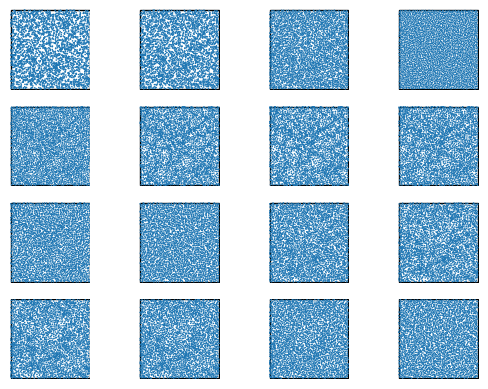

In [14]:
animation       = [ INITIAL_SEEDS ]
last_velocities = velocities
for i in trange(31):
    current_seeds, last_velocities, _ = euler_step(animation[-1], last_velocities, masses)
    
    animation    += [ current_seeds ]
    animation[-1] = np.clip(animation[-1], 0., 1.)

plot_particles_sequence(animation[::2])

It works! But as you may have noticed, there is nothing interesting going on here.

To make things funnier, we create a new set of particles and their attributes:

In [15]:
seeds      = centroids(optimizer.solve(INITIAL_SEEDS))
velocities = np.zeros_like(INITIAL_SEEDS)
masses     = np.ones(len(INITIAL_SEEDS))

To create a good starting point to simulate Rayleigh-Taylor Instability, we select some particles above a given sine wave and assign them a higher mass than bottom particles:

In [16]:
labels = (seeds[:, 1] - .5) > .1 * np.sin(seeds[:, 0] * 10.)
masses[labels] = 3

Since that we now simulate the fluids with some cells, we rely on them for plots. We also let the user provides some labels to color the cells.

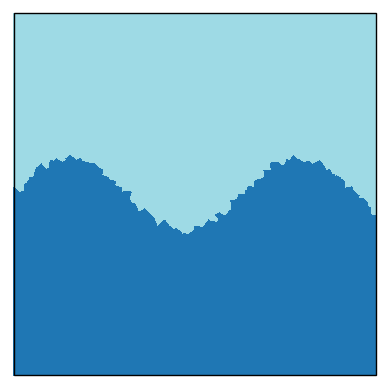

In [17]:
def plot_particles_sequence(voronois, labels):
    img_nb    = len(voronois)
    _, axes = plt.subplots( int( np.ceil(img_nb / 4) ), min( img_nb, 4 ) )
    for img in range(img_nb):
        current = voronois[img]
        
        ax = axes if img_nb == 1 else (axes[img] if img_nb <= 4 else axes[img // 4, img % 4])
            
        triangulation = tri.Triangulation(current.q[:, 0], current.q[:, 1], current.t)
        ax.tripcolor(triangulation, labels[current.tseed], shading='flat', cmap='tab20')
        ax.add_patch( matplotlib.patches.Rectangle((0, 0), 1, 1, color='black', fc = 'none',lw = 1))

        ax.set_aspect('equal')
        ax.margins(0.01)
        ax.axis('off')


voronoi = geo.Voronoi(seeds, domain_vertices=domain_vertices, domain_simplices=domain_triangles)
plot_particles_sequence([voronoi], labels)

We are now ready to compute our new simulation:

In [ ]:
last_seeds      = seeds
last_velocities = velocities
animation       = []
for i in trange(512):
    last_seeds, last_velocities, voronoi = euler_step(last_seeds, last_velocities, masses)
    last_seeds = np.clip(last_seeds, 0., 1.)

    animation += [ voronoi ]
    
plot_particles_sequence(animation[::64], labels)

  9%|▉         | 47/512 [00:03<00:34, 13.36it/s]

If you want to see the complete animation as a video, you can also use the following script to generate a set of images a given folder:

In [ ]:
import os

OUT_FOLDER = 'out'
os.makedirs(os.getcwd() + os.sep + OUT_FOLDER, exist_ok=True)

last_seeds      = seeds
last_velocities = velocities
for i in range(512):
    last_seeds, last_velocities, voronoi = euler_step(last_seeds, last_velocities, masses)
    last_seeds = np.clip(last_seeds, 0., 1.)

    # Plot 
    fig, ax = plt.subplots( 1, 1 )
    ax.add_patch( matplotlib.patches.Rectangle((0, 0), 1, 1, color='black', fc = 'none',lw = 1))

    triangulation = tri.Triangulation(voronoi.q[:, 0], voronoi.q[:, 1], voronoi.t)
    ax.tripcolor(triangulation, labels[voronoi.tseed], shading='flat', cmap='tab20')

    ax.set_aspect('equal')
    ax.margins(0.01)
    ax.axis('off')

    # Save figure
    os.makedirs(os.getcwd() + '/out', exist_ok=True)
    fig.savefig(os.getcwd() + os.sep + OUT_FOLDER + os.sep + '{0:04d}.png'.format(i))
    plt.close()